In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#build vocabulary of characters and int mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#build dataset
block_size = 3 #context length
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '-->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
olivia
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
ava
... --> a
..a --> v
.av --> a
ava --> .
isabella
... --> i
..i --> s
.is --> a
isa --> b
sab --> e
abe --> l
bel --> l
ell --> a
lla --> .
sophia
... --> s
..s --> o
.so --> p
sop --> h
oph --> i
phi --> a
hia --> .


In [6]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [7]:
# first come up with embedding C X-->N-vector
#27 characters into 2d space
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
C

tensor([[ 1.5674, -0.2373],
        [-0.0274, -1.1008],
        [ 0.2859, -0.0296],
        [-1.5471,  0.6049],
        [ 0.0791,  0.9046],
        [-0.4713,  0.7868],
        [-0.3284, -0.4330],
        [ 1.3729,  2.9334],
        [ 1.5618, -1.6261],
        [ 0.6772, -0.8404],
        [ 0.9849, -0.1484],
        [-1.4795,  0.4483],
        [-0.0707,  2.4968],
        [ 2.4448, -0.6701],
        [-1.2199,  0.3031],
        [-1.0725,  0.7276],
        [ 0.0511,  1.3095],
        [-0.8022, -0.8504],
        [-1.8068,  1.2523],
        [ 0.1476, -1.0006],
        [-0.5030, -1.0660],
        [ 0.8480,  2.0275],
        [-0.1158, -1.2078],
        [-1.0406, -1.5367],
        [-0.5132,  0.2961],
        [-1.4904, -0.2838],
        [ 0.2569,  0.2130]])

In [8]:
#basic way to "embed" a value '5': just index into matrix
C[5]

tensor([-0.4713,  0.7868])

In [9]:
#or use one-hot to encode into binary sequence
example = F.one_hot(torch.tensor(5), num_classes=27).float()
#multiply one hot by C to be equivalent of indexing into it
example @ C

tensor([-0.4713,  0.7868])

In [10]:
#index with a list
C[[5,6,7]]

tensor([[-0.4713,  0.7868],
        [-0.3284, -0.4330],
        [ 1.3729,  2.9334]])

In [11]:
#index with a tensor of integers
C[torch.tensor([5,6,7,7,7])]

tensor([[-0.4713,  0.7868],
        [-0.3284, -0.4330],
        [ 1.3729,  2.9334],
        [ 1.3729,  2.9334],
        [ 1.3729,  2.9334]])

In [12]:
#index with a multidimensional tensor of integers
C[X].shape #for each of 32x3 integers, retreived 2D vector:

torch.Size([32, 3, 2])

In [13]:
print(C[X][13,2])
print(C[1])

tensor([-0.0274, -1.1008])
tensor([-0.0274, -1.1008])


In [14]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [15]:
#construct hidden layer
W1 = torch.randn((6, 100)) #Layer: inputs: 3chars*2Dim embedding, 100 neurons
b1 = torch.randn(100)


In [16]:
#roughly want emb @ W1 + B1
#but this is 32x3x2  @ 6x100 --> Won't work! 
#need to concantenate the inputs (technically many ways to do this)
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)


tensor([[ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -0.4713,  0.7868],
        [ 1.5674, -0.2373, -0.4713,  0.7868,  2.4448, -0.6701],
        [-0.4713,  0.7868,  2.4448, -0.6701,  2.4448, -0.6701],
        [ 2.4448, -0.6701,  2.4448, -0.6701, -0.0274, -1.1008],
        [ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -1.0725,  0.7276],
        [ 1.5674, -0.2373, -1.0725,  0.7276, -0.0707,  2.4968],
        [-1.0725,  0.7276, -0.0707,  2.4968,  0.6772, -0.8404],
        [-0.0707,  2.4968,  0.6772, -0.8404, -0.1158, -1.2078],
        [ 0.6772, -0.8404, -0.1158, -1.2078,  0.6772, -0.8404],
        [-0.1158, -1.2078,  0.6772, -0.8404, -0.0274, -1.1008],
        [ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -0.0274, -1.1008],
        [ 1.5674, -0.2373, -0.0274, -1.1008, -0.1158, -1.2078],
        [-0.0274, -1.1008, -0.1158, -1.2

In [17]:
#another way to concatenate
torch.cat(torch.unbind(emb, 1), 1)

tensor([[ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -0.4713,  0.7868],
        [ 1.5674, -0.2373, -0.4713,  0.7868,  2.4448, -0.6701],
        [-0.4713,  0.7868,  2.4448, -0.6701,  2.4448, -0.6701],
        [ 2.4448, -0.6701,  2.4448, -0.6701, -0.0274, -1.1008],
        [ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -1.0725,  0.7276],
        [ 1.5674, -0.2373, -1.0725,  0.7276, -0.0707,  2.4968],
        [-1.0725,  0.7276, -0.0707,  2.4968,  0.6772, -0.8404],
        [-0.0707,  2.4968,  0.6772, -0.8404, -0.1158, -1.2078],
        [ 0.6772, -0.8404, -0.1158, -1.2078,  0.6772, -0.8404],
        [-0.1158, -1.2078,  0.6772, -0.8404, -0.0274, -1.1008],
        [ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -0.0274, -1.1008],
        [ 1.5674, -0.2373, -0.0274, -1.1008, -0.1158, -1.2078],
        [-0.0274, -1.1008, -0.1158, -1.2

In [18]:
#An even better way to concantenate:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [19]:
a.view(9,2)

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [20]:
emb.shape

torch.Size([32, 3, 2])

In [21]:
emb.view(32,6) == torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [22]:
#to make our neuron layer:
#emb.view(32, 6) @ W1 + B1
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #-1 tells pytorch to figure it out
#be careful with broadcasting between matrix and B1
#32, 100
#    100
(emb.view(-1, 6) @ W1).shape[1] == b1.shape[0]

True

In [23]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

logits = h @ W2 + b2

In [24]:
counts = logits.exp()
prob = counts/counts.sum(1, keepdims=True)
prob.shape

torch.Size([32, 27])

In [25]:
#Actual error (for loss):
loss = -prob[torch.arange(32), Y].log().mean() #negative log likelihood loss
loss

tensor(17.3591)

In [26]:
#REWRITE
#build dataset
block_size = 3 #context length
X, Y = [], []
for w in words:
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100)) #Layer: inputs: 3chars*2Dim embedding, 100 neurons
b1 = torch.randn(100)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad=True

for _ in range (50):
    #forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    #manually implement classification math:
    #counts = logits.exp()
    #prob = counts/counts.sum(1, keepdims=True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    
    #use pytorch cross_entropy
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -0.1*p.grad

print("Final Loss: ", loss.item())

14.135153770446777
13.215675354003906
12.531742095947266
11.985100746154785
11.490887641906738
11.037908554077148
10.629432678222656
10.26501750946045
9.934053421020508
9.627883911132812
9.343514442443848
9.079200744628906
8.833211898803711
8.603803634643555
8.389246940612793
8.187915802001953
7.998376369476318
7.819430828094482
7.650092601776123
7.489625930786133
7.337557315826416
7.1935930252075195
7.057483673095703
6.92889928817749
6.807356834411621
6.6922430992126465
6.582864761352539
6.47855806350708
6.37877082824707
6.283083438873291
6.191185474395752
6.1028361320495605
6.017840385437012
5.936033248901367
5.857273101806641
5.781435966491699
5.708413124084473
5.638105869293213
5.570423126220703
5.505275726318359
5.442578315734863
5.3822407722473145
5.324172496795654
5.268279075622559
5.214465618133545
5.162635803222656
5.112690448760986
5.0645341873168945
5.018072128295898
4.973212242126465
Final Loss:  4.973212242126465


In [38]:
#With batching:
block_size = 3 #context length
X, Y = [], []
for w in words:
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100)) #Layer: inputs: 3chars*2Dim embedding, 100 neurons
b1 = torch.randn(100)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad=True

#learning rate
lre = torch.linspace(-3, 0, 1000) #creates 1000 values between .001 and 1, non linearly
lrs = 10**lre
#track losses by learning rate
lri = []
lossi = []

for i in range (10000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    #forward pass
    emb = C[X[ix]] #again, 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr*p.grad
    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print("Final Loss: ", loss.item())

Final Loss:  2.4223904609680176


In [36]:
#loss for all X and Y
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.item())

9.730231285095215


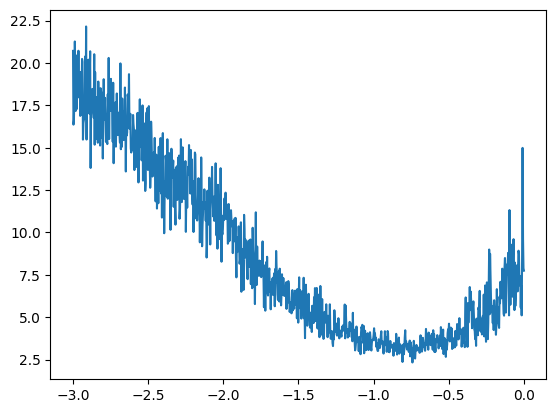

In [37]:
plt.plot(lri, lossi)

In [62]:
#split data into train/dev/test
def build_dataset(words):
    block_size = 3 #context length
    X, Y = [], []
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])



In [63]:
Xte

tensor([[ 0,  0,  0],
        [ 0,  0, 11],
        [ 0, 11, 18],
        ...,
        [ 0, 10,  5],
        [10,  5,  1],
        [ 5,  1, 14]])

In [64]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100)) #Layer: inputs: 3chars*2Dim embedding, 100 neurons
b1 = torch.randn(100)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad=True

In [77]:
#Train
for i in range (100):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #forward pass
    emb = C[Xtr[ix]] #again, 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad
    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print("Final Loss: ", loss.item())

Final Loss:  2.6654036045074463


In [78]:
#evaluate on DEV set
ix = torch.randint(0, Xdev.shape[0], (32,))
emb = C[Xdev[ix]] #again, 32x3x2
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev[ix])
print(loss.item())

2.4529953002929688


In [83]:
#scale up
block_size = 3 #context length
X, Y = [], []
for w in words:
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300)) #Layer: inputs: 3chars*2Dim embedding, 100 neurons
b1 = torch.randn(300)
W2 = torch.randn((300, 27))
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad=True


stepi = []
lossi = []
for i in range (30000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    #forward pass
    emb = C[X[ix]] #again, 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr*p.grad
    #track stats
    stepi.append(i)
    lossi.append(loss.item())

print("Final Loss: ", loss.item())

Final Loss:  2.871976375579834


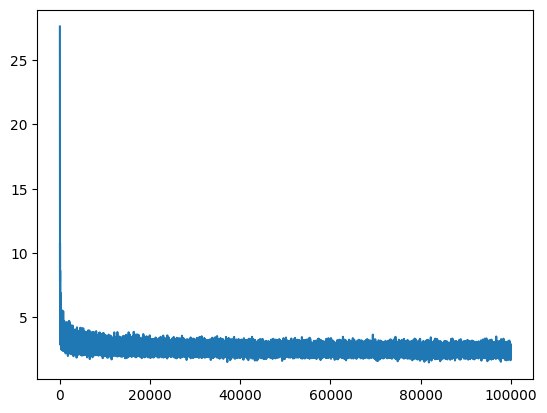

In [84]:
plt.plot(stepi, lossi)

In [91]:
for i in range (10000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    #forward pass
    emb = C[X[ix]] #again, 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad
    #track stats
    stepi.append(i)
    lossi.append(loss.item())

print("Final Loss: ", loss.item())
#loss for all X and Y
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.item())

Final Loss:  2.226638078689575
2.20928955078125


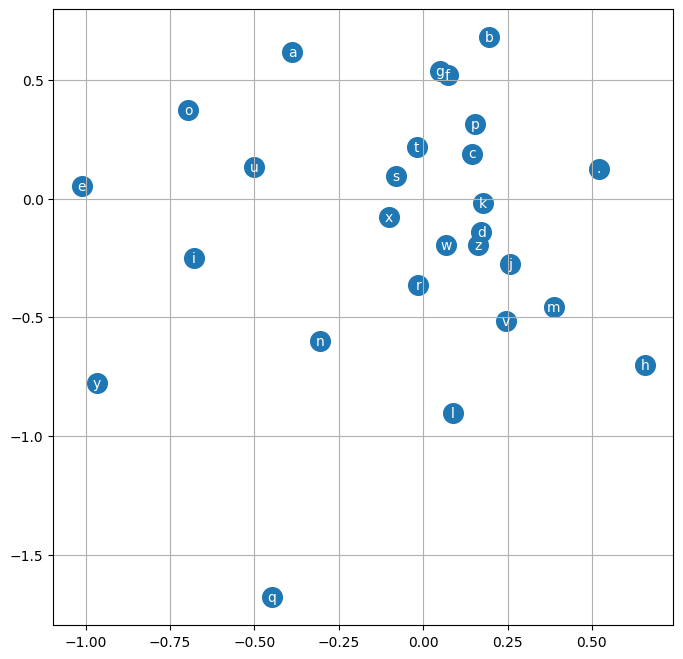

In [92]:
#visualize embedding vectors
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [98]:
#scaling neurons didn't improve loss much, so now try scaling embeddings:
block_size = 3 #context length
X, Y = [], []
for w in words:
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g) #10D embeddings for each word
W1 = torch.randn((3*10, 200)) #Layer: inputs: 3chars*2Dim embedding, 100 neurons
b1 = torch.randn(200)
W2 = torch.randn((200, 27))
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad=True

In [99]:
stepi = []
lossi = []

In [102]:
for i in range (30000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    #forward pass
    emb = C[X[ix]] #again, 32x3x2
    h = torch.tanh(emb.view(-1, 3*10) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.1/10
    for p in parameters:
        p.data += -lr*p.grad
    #track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

print("Final Loss: ", loss.item())

Final Loss:  2.24558687210083


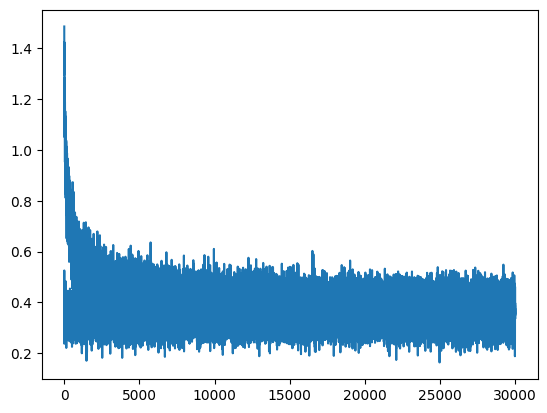

In [103]:
plt.plot(stepi, lossi)

In [ ]:
#sample from model

g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @W1+b1)
        logits = h @ W2+b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))